In [7]:
import pandas as pd

In [9]:
dataset = pd.read_csv("C:/Users/Siddhesh/Downloads/loan_data.csv")
dataset.head(10)

,Income,LoanAmount,CreditScore,LoanTerm,Default
0,57450.712295,18891.805381,516.453471,24,0.0
1,47926.035482,12244.071418,589.773049,36,0.0
2,59715.328072,10909.005583,621.047613,24,0.0
3,72845.447846,14983.127713,782.138136,24,1.0
4,46487.699379,14149.076887,688.958719,12,1.0
5,46487.945646,12733.859753,556.516290,24,0.0
6,73688.192233,18481.937237,684.022540,24,0.0
7,61511.520937,19776.526043,541.688721,36,0.0
8,42957.884211,15442.034431,725.788374,36,0.0
9,58138.400654,22387.650405,617.021274,48,0.0


In [3]:
dataset.shape

(1500, 5)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Income       1500 non-null   float64
 1   LoanAmount   1500 non-null   float64
 2   CreditScore  1500 non-null   float64
 3   LoanTerm     1500 non-null   int64  
 4   Default      1500 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 58.7 KB


In [5]:
dataset.dtypes

Income         float64
LoanAmount     float64
CreditScore    float64
LoanTerm         int64
Default        float64
dtype: object

In [6]:
dataset.describe()

,Income,LoanAmount,CreditScore,LoanTerm,Default
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50745.906061,15077.242788,646.900015,35.168000,0.135333
std,14823.318239,4909.746103,71.002499,16.950142,0.342193
min,10000.000000,1000.000000,439.465736,12.000000,0.000000
25%,40639.529526,11822.943740,598.503091,24.000000,0.000000
50%,50756.044671,14989.792370,648.524658,36.000000,0.000000
75%,60201.102291,18353.477410,692.866859,48.000000,0.000000
max,107790.972360,34631.188532,850.000000,60.000000,1.000000


# Preprocessing Data

In [8]:
dataset.isnull()

,Income,LoanAmount,CreditScore,LoanTerm,Default
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1495,False,False,False,False,False
1496,False,False,False,False,False
1497,False,False,False,False,False
1498,False,False,False,False,False


In [9]:
dataset.isnull().sum()

Income         0
LoanAmount     0
CreditScore    0
LoanTerm       0
Default        0
dtype: int64

# Data Visualisation 

### 1. Distribution of Numerical Features

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

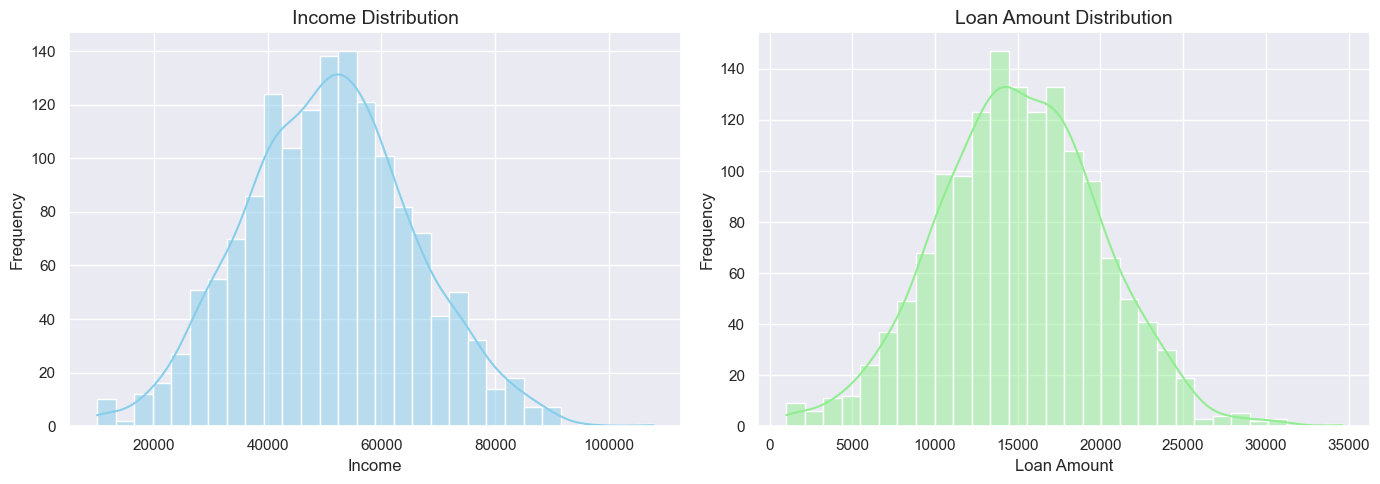

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme
sns.set(style='darkgrid')

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Income Distribution
sns.histplot(dataset['Income'], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title("Income Distribution", fontsize=14)
axes[0].set_xlabel("Income", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)

# Plot Loan Amount Distribution
sns.histplot(dataset['LoanAmount'], kde=True, bins=30, ax=axes[1], color='lightgreen')
axes[1].set_title("Loan Amount Distribution", fontsize=14)
axes[1].set_xlabel("Loan Amount", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)

# Improve layout
plt.tight_layout()
plt.show()


## 2. Loan Term count plot

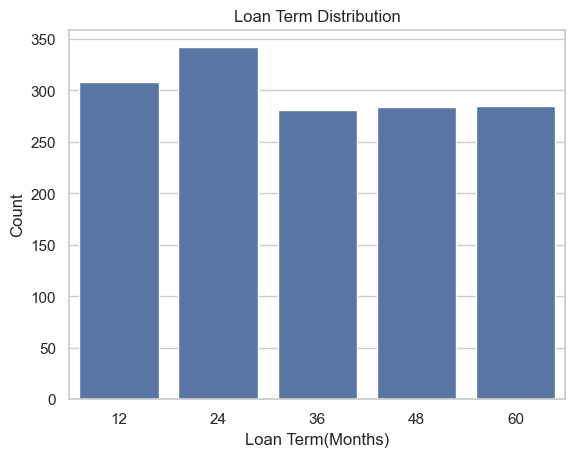

In [15]:
sns.countplot(x="LoanTerm",data=dataset)
plt.title("Loan Term Distribution")
plt.xlabel("Loan Term(Months)")
plt.ylabel("Count")
plt.show()

## 3. Loan Default Distribution

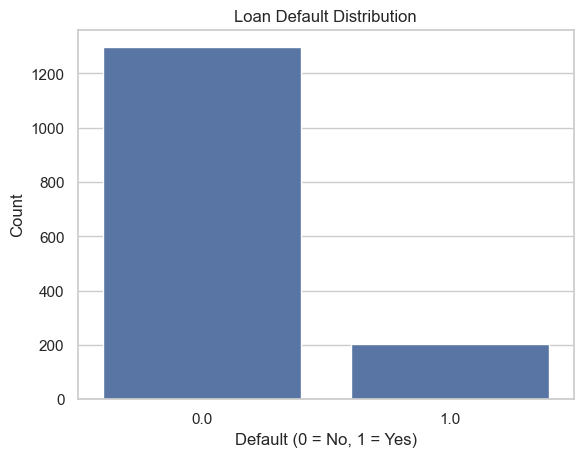

In [17]:
sns.countplot(x='Default', data=dataset)
plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## 4. Correlation Heatmap

<function matplotlib.pyplot.show(close=None, block=None)>

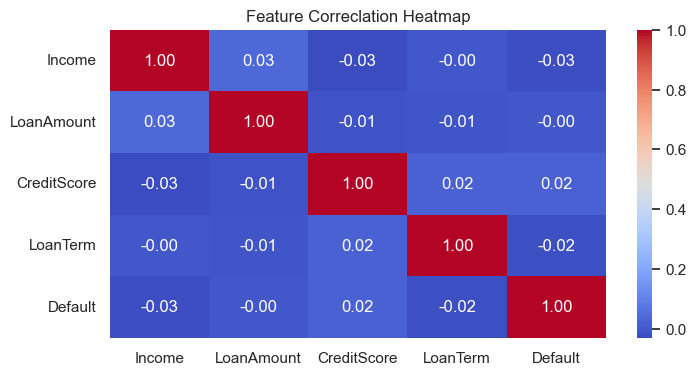

In [19]:
plt.figure(figsize=(8, 4))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correclation Heatmap")
plt.show

## 5. Feature Engineering

In [21]:
dataset["LoanTerm_Binary"] = dataset["LoanTerm"].apply(lambda x:1 if x==60 else 0)

In [22]:
import numpy as np
dataset["log_Income"] = np.log1p(dataset["Income"])
dataset["Log_Loan_Amount"] = np.log1p(dataset["LoanAmount"])

In [23]:
features = ["log_Income","Log_Loan_Amount","CreditScore"]
target = "Default"

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scale_features = ["log_Income","Log_Loan_Amount"]
dataset[scale_features] = scaler.fit_transform(dataset[scale_features])
dataset.head()

,Income,LoanAmount,CreditScore,LoanTerm,Default,LoanTerm_Binary,log_Income,Log_Loan_Amount
0,57450.712295,18891.805381,516.453471,24,0.0,0,0.524342,0.715378
1,47926.035482,12244.071418,589.773049,36,0.0,0,-0.024819,-0.341502
2,59715.328072,10909.005583,621.047613,24,0.0,0,0.641469,-0.622852
3,72845.447846,14983.127713,782.138136,24,1.0,0,1.243597,0.150476
4,46487.699379,14149.076887,688.958719,12,1.0,0,-0.117133,0.010898


## Using Classification Algorithms

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [27]:
x = dataset.iloc[:, dataset.columns != "Default"]
y = dataset["Default"]

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Logistic Regression

In [33]:
lr = LogisticRegression(max_iter=1000)

In [35]:
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [57]:
lr.score(x_train,y_train)*100 , lr.score(x_test,y_test)*100

(86.16666666666667, 87.66666666666667)

##  Precision

In [69]:
sample = [[57450.71, 18891.80, 516.45, 24, 0, 0.52, 0.71]]
lr.predict(sample)


C:\Users\Siddhesh\Downloads\anacondaa\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0.])

In [75]:
y_pred = lr.predict(x)
y_pred

array([0., 0., 0., ..., 0., 0., 0.])

## recall

In [93]:
from sklearn.metrics import recall_score

In [84]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [86]:
y_pred = model.predict(x_test)


In [88]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")


Recall: 0.0000


## F1 Score

In [91]:
from sklearn.metrics import f1_score


In [95]:
score = f1_score(y_test, y_pred)
print(f"F1 Score: {score:.4f}")

F1 Score: 0.0000


In [108]:
from sklearn.metrics import roc_auc_score, roc_curve


In [110]:
y_proba = model.predict_proba(x_test)[:, 1]  

In [112]:
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")


ROC-AUC Score: 0.4574


## Decision Tree Classifier

In [42]:
from sklearn.tree import DecisionTreeClassifier

In [51]:
dtc = DecisionTreeClassifier()

In [53]:
dtc.fit(x_train, y_train)       

DecisionTreeClassifier()

In [55]:
dtc.score(x_train,y_train)*100 , dtc.score(x_test,y_test)*100

(100.0, 77.0)

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
rfc = RandomForestClassifier()

In [63]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [65]:
rfc.score(x_train,y_train)*100 , rfc.score(x_test,y_test)*100

(99.91666666666667, 87.0)

## By Using This Classification Algorithms Random Forest Classifier gives more accurate and well train the model 

## ROC-AUC

In [100]:
from sklearn.metrics import roc_auc_score, roc_curve


In [104]:
y_proba = model.predict_proba(x_test)[:, 1]  


In [106]:
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {auc:.4f}")


ROC-AUC Score: 0.4574
